# Actividad 4 — Calidad · Agraria.pe

**Objetivo:** Auditar la calidad del dataset de noticias: nulos, fechas invalidas, duplicados y noticias sin contenido util.


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    if not isinstance(t, str): return ''
    t = unicodedata.normalize('NFKD', t).encode('ASCII','ignore').decode('utf-8')
    return t.upper().strip()

def reporte_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    r = pd.DataFrame({'nulos': nulos, 'pct': pct})
    r = r[r['nulos'] > 0].sort_values('nulos', ascending=False)
    print(f'=== NULOS EN {nombre} ===')
    if len(r) == 0:
        print('  Sin valores nulos.')
    else:
        print(r.to_string())
    print()
    return r

def outliers_iqr(serie, nombre):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (serie < lower) | (serie > upper)
    n_out = mask.sum()
    pct = n_out / len(serie) * 100
    print(f'{nombre}: Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f}')
    print(f'  Limite inferior: {lower:.2f} | Limite superior: {upper:.2f}')
    print(f'  Outliers: {n_out} ({pct:.2f}%)')
    return lower, upper, mask

print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos


In [2]:
df_agr = pd.read_csv(OUTPUT['lectura'] + 'agraria_raw.csv',
                     on_bad_lines='skip', low_memory=False)
df_agr['fecha_dt'] = pd.to_datetime(df_agr['fecha'], errors='coerce')
df_agr['anio'] = df_agr['fecha_dt'].dt.year
print(f'Shape: {df_agr.shape}')
print(f'Columnas: {df_agr.columns.tolist()}')


Shape: (528, 9)
Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo', 'fecha_dt', 'anio', 'mes']


## 4.1 Auditoria de Nulos


=== NULOS POR COLUMNA — AGRARIA.PE ===
  fecha                    0 nulos (0.00%)  [OK]
  titular                  0 nulos (0.00%)  [OK]
  cuerpo_completo          0 nulos (0.00%)  [OK]
  fuente                   0 nulos (0.00%)  [OK]
  url                      0 nulos (0.00%)  [OK]


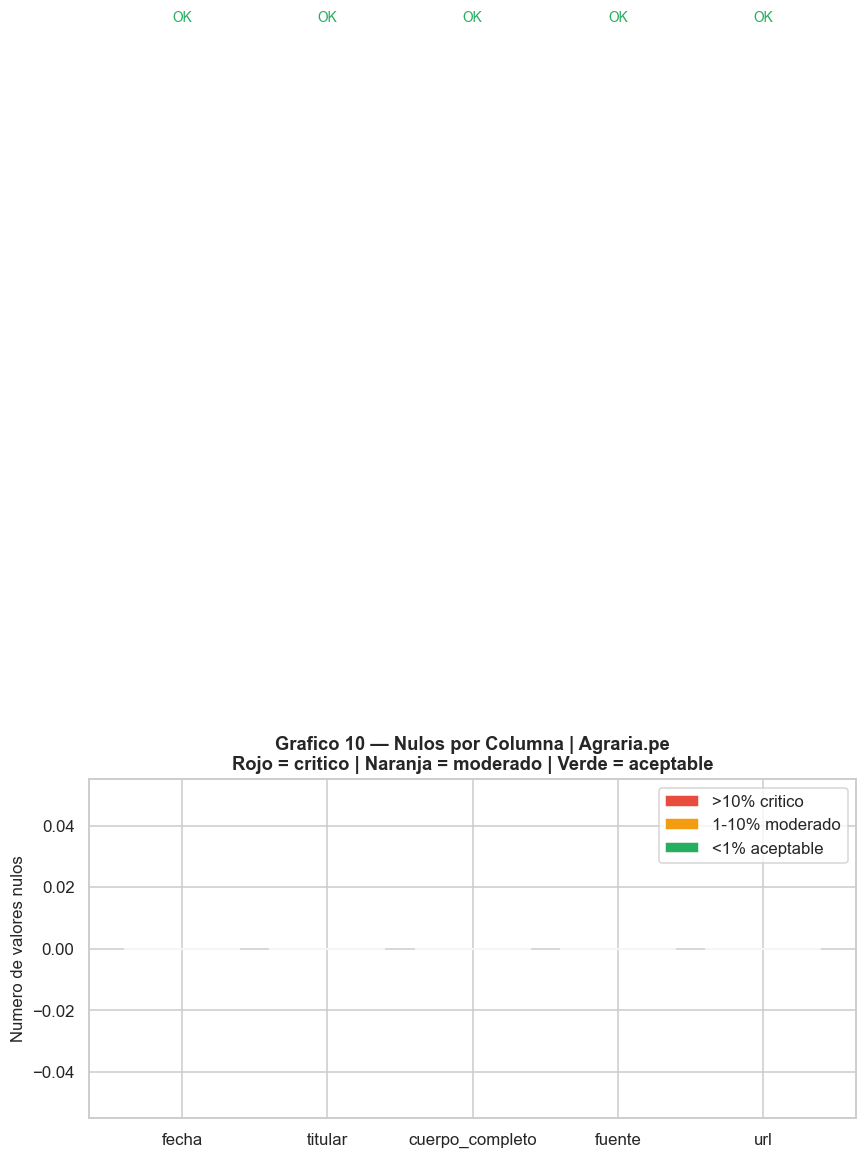

Guardado: pipeline/output/04_calidad/act04_agraria_g10_nulos.png


In [3]:
cols_check = ['fecha','titular','cuerpo_completo','fuente','url']
cols_check = [c for c in cols_check if c in df_agr.columns]
nulos_agr = df_agr[cols_check].isnull().sum()
pct_agr   = (nulos_agr / len(df_agr) * 100).round(2)

print('=== NULOS POR COLUMNA — AGRARIA.PE ===')
for col, n, p in zip(nulos_agr.index, nulos_agr.values, pct_agr.values):
    nivel = 'CRITICO' if p > 10 else 'MODERADO' if p > 1 else 'OK'
    print(f'  {col:<20} {n:>5,} nulos ({p:.2f}%)  [{nivel}]')

# Grafico G10
fig, ax = plt.subplots(figsize=(9, 4))
colors_n = ['#e74c3c' if p > 10 else '#f39c12' if p > 1 else '#27ae60'
            for p in pct_agr.values]
bars = ax.bar(nulos_agr.index, nulos_agr.values, color=colors_n, edgecolor='white')
for bar, val, p in zip(bars, nulos_agr.values, pct_agr.values):
    label = f'{val}\n({p}%)' if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3 if val > 0 else 0.3,
            label, ha='center', va='bottom', fontsize=9, color=color)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 10 — Nulos por Columna | Agraria.pe\n'
             'Rojo = critico | Naranja = moderado | Verde = aceptable',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='>10% critico'),
                   Patch(facecolor='#f39c12', label='1-10% moderado'),
                   Patch(facecolor='#27ae60', label='<1% aceptable')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_agraria_g10_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Nulos en cuerpo_completo y otras columnas de texto  
**Magnitud:** Ver tabla de nulos arriba  
**Decision (Actividad 5):** En la Actividad 5 se eliminaran noticias sin titular. Las sin cuerpo se conservan para el conteo mensual.


## 4.2 Fechas Invalidas o Fuera de Rango


In [4]:
fechas_nulas = df_agr['fecha_dt'].isnull().sum()
fechas_fuera = ((df_agr['anio'] < 2021) | (df_agr['anio'] > 2025)).sum()

print(f'Fechas no parseables: {fechas_nulas} ({fechas_nulas/len(df_agr)*100:.2f}%)')
print(f'Fechas fuera del rango 2021-2025: {fechas_fuera} ({fechas_fuera/len(df_agr)*100:.2f}%)')
print()
print('Distribucion por año:')
print(df_agr['anio'].value_counts().sort_index().to_string())
print()
if fechas_nulas > 0:
    print('Muestra de fechas no parseables:')
    print(df_agr[df_agr['fecha_dt'].isnull()]['fecha'].head(5).tolist())


Fechas no parseables: 0 (0.00%)
Fechas fuera del rango 2021-2025: 0 (0.00%)

Distribucion por año:
anio
2021     44
2022    133
2023    118
2024    108
2025    125



### Decision tecnica documentada

**Problema:** Fechas no parseables o fuera del rango 2021-2025  
**Magnitud:** Ver conteo arriba  
**Decision (Actividad 5):** En la Actividad 5 se eliminaran las noticias con fecha invalida o fuera del rango del pipeline.


## 4.3 Auditoria de Duplicados


Duplicados por URL: 0 (0.00%)
Duplicados por titular+fecha: 0 (0.00%)



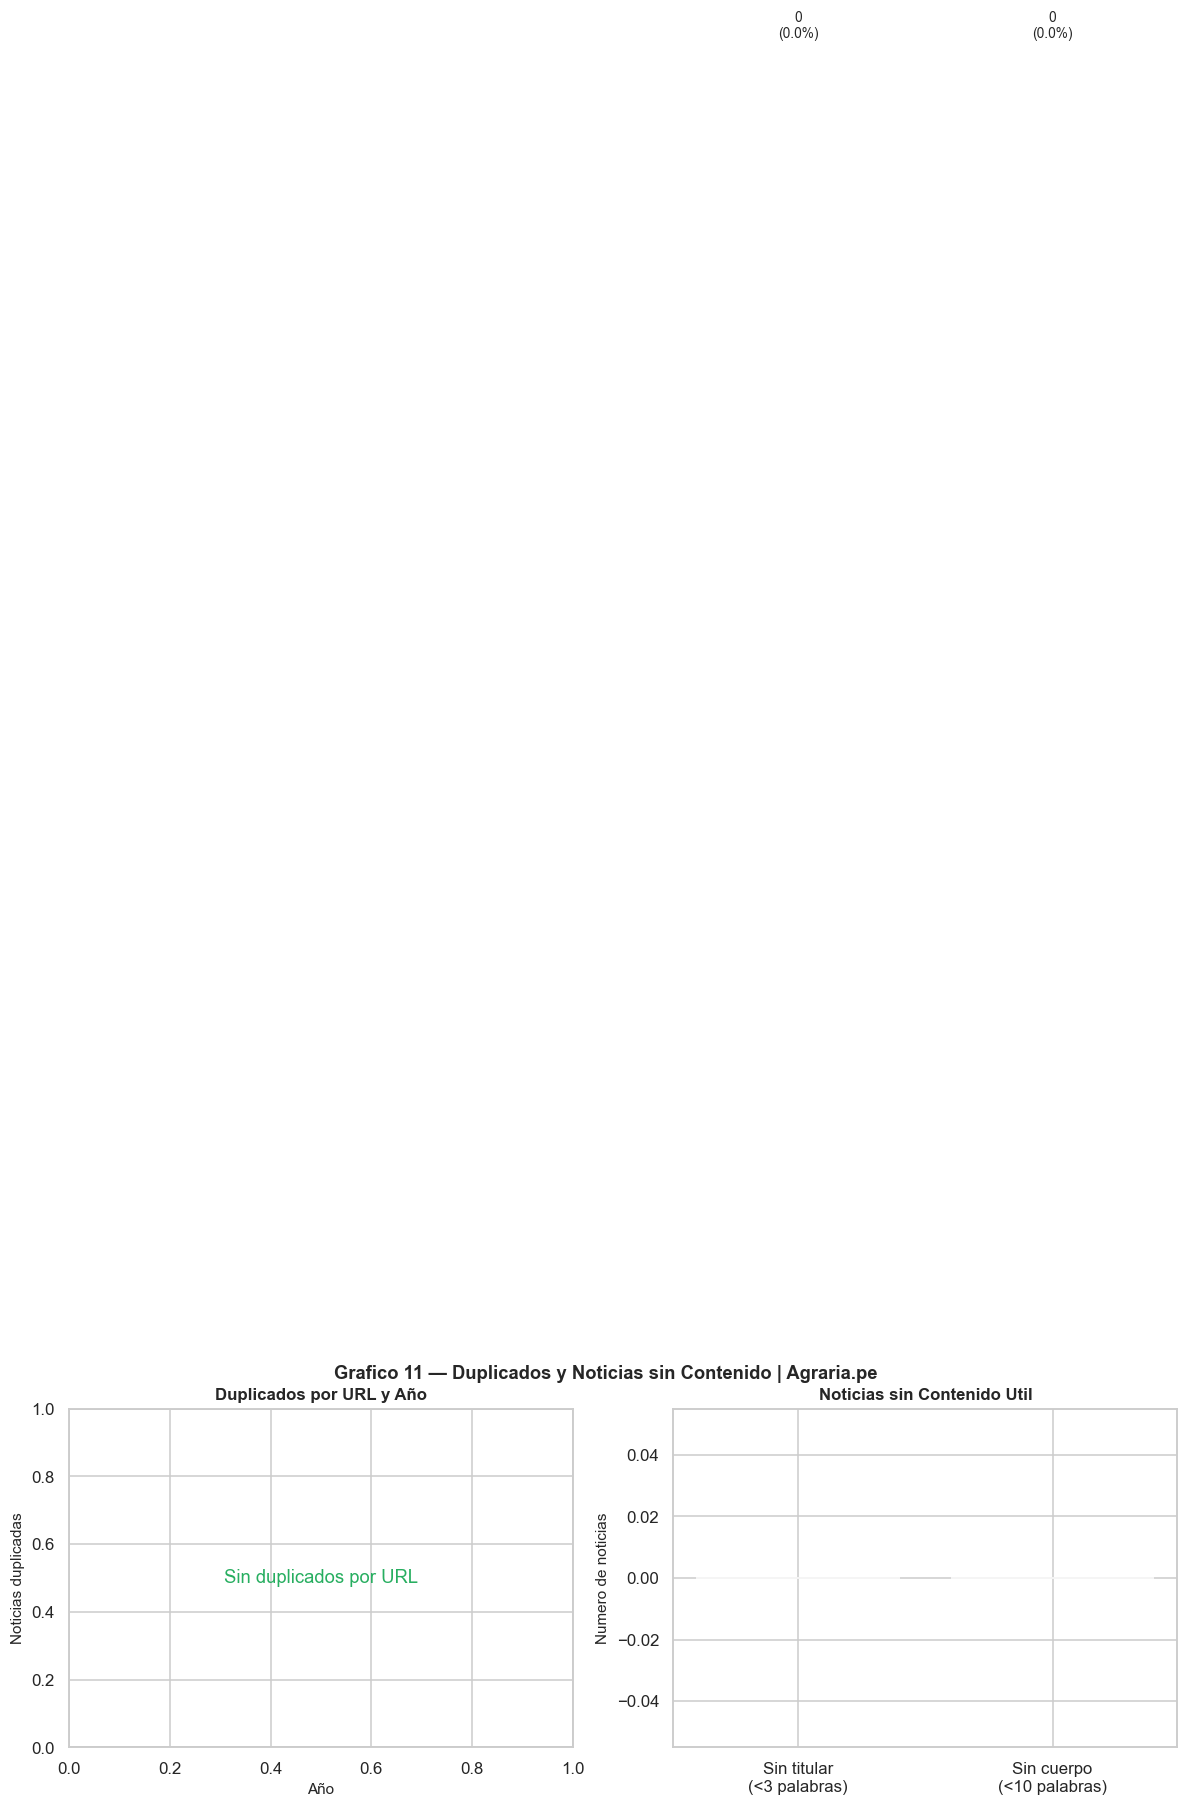

Guardado: pipeline/output/04_calidad/act04_agraria_g11_duplicados.png
Noticias sin titular util (<3 palabras): 0
Noticias sin cuerpo util (<10 palabras): 0


In [5]:
# Duplicados por URL
dup_url = df_agr['url'].duplicated().sum() if 'url' in df_agr.columns else 0
# Duplicados por titular + fecha
dup_tit = df_agr.duplicated(subset=['titular','fecha'], keep=False).sum()

print(f'Duplicados por URL: {dup_url} ({dup_url/len(df_agr)*100:.2f}%)')
print(f'Duplicados por titular+fecha: {dup_tit} ({dup_tit/len(df_agr)*100:.2f}%)')
print()

# Duplicados por año
dup_por_anio = df_agr[df_agr.duplicated(subset=['url'], keep=False)].groupby('anio').size()

# Grafico G11
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: duplicados por año
if len(dup_por_anio) > 0:
    axes[0].bar(dup_por_anio.index.astype(str), dup_por_anio.values,
                color='#e74c3c', edgecolor='white')
    for i, val in enumerate(dup_por_anio.values):
        axes[0].text(i, val+0.5, str(val), ha='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'Sin duplicados por URL', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=12, color='#27ae60')
axes[0].set_xlabel('Año', fontsize=10)
axes[0].set_ylabel('Noticias duplicadas', fontsize=10)
axes[0].set_title('Duplicados por URL y Año', fontsize=11, fontweight='bold')

# Panel 2: noticias sin contenido util
df_agr['len_titular'] = df_agr['titular'].fillna('').apply(lambda x: len(str(x).split()))
df_agr['len_cuerpo']  = df_agr['cuerpo_completo'].fillna('').apply(lambda x: len(str(x).split()))
sin_titular = (df_agr['len_titular'] < 3).sum()
sin_cuerpo  = (df_agr['len_cuerpo'] < 10).sum()
categorias = ['Sin titular\n(<3 palabras)', 'Sin cuerpo\n(<10 palabras)']
valores = [sin_titular, sin_cuerpo]
colors_util = ['#e74c3c' if v > 0 else '#27ae60' for v in valores]
axes[1].bar(categorias, valores, color=colors_util, edgecolor='white')
for i, val in enumerate(valores):
    axes[1].text(i, val+0.5, f'{val}\n({val/len(df_agr)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[1].set_ylabel('Numero de noticias', fontsize=10)
axes[1].set_title('Noticias sin Contenido Util', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 11 — Duplicados y Noticias sin Contenido | Agraria.pe',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_agraria_g11_duplicados.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Noticias sin titular util (<3 palabras): {sin_titular}')
print(f'Noticias sin cuerpo util (<10 palabras): {sin_cuerpo}')


### Decision tecnica documentada

**Problema:** Noticias duplicadas (misma URL) y noticias sin contenido util  
**Magnitud:** Ver conteo de duplicados y noticias sin contenido arriba  
**Decision (Actividad 5):** En la Actividad 5 se deduplicara por URL y se eliminaran noticias sin titular util.


In [6]:
reporte = [
    'REPORTE DE CALIDAD — AGRARIA.PE',
    '=' * 60,
    f'Noticias totales: {len(df_agr):,}',
    f'Fechas no parseables: {fechas_nulas}',
    f'Fechas fuera de rango 2021-2025: {fechas_fuera}',
    f'Duplicados por URL: {dup_url}',
    f'Duplicados por titular+fecha: {dup_tit}',
    f'Sin titular util (<3 palabras): {sin_titular}',
    f'Sin cuerpo util (<10 palabras): {sin_cuerpo}',
]
for col, n, p in zip(nulos_agr.index, nulos_agr.values, pct_agr.values):
    if n > 0:
        reporte.append(f'Nulos {col}: {n} ({p}%)')

reporte_txt = '\n'.join(reporte)
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_agraria.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - AGRARIA.PE] COMPLETADA.')


REPORTE DE CALIDAD — AGRARIA.PE
Noticias totales: 528
Fechas no parseables: 0
Fechas fuera de rango 2021-2025: 0
Duplicados por URL: 0
Duplicados por titular+fecha: 0
Sin titular util (<3 palabras): 0
Sin cuerpo util (<10 palabras): 0

[ACTIVIDAD 4 - AGRARIA.PE] COMPLETADA.
